In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

df=pd.read_csv("Global_Sports_Footwear_sales_2018_2026_Dataset.csv")

Checking if the data is not clean

In [3]:
df.head()

,order_id,order_date,brand,model_name,category,gender,size,color,base_price_usd,discount_percent,f,units_sold,revenue_usd,payment_method,sales_channel,country,customer_income_level,customer_rating
0,ORD100000,2021-01-30,ASICS,Model-370,Running,Unisex,8,Black,162,15,137.70,1,137.7,Card,Retail Store,Germany,Low,4.6
1,ORD100001,2026-10-05,Reebok,Model-314,Lifestyle,Men,8,Grey,80,5,76.00,3,228.0,Card,Online,USA,Low,3.9
2,ORD100002,2023-11-12,ASICS,Model-763,Lifestyle,Men,8,Black,176,15,149.60,4,598.4,Cash,Retail Store,India,Medium,3.0
3,ORD100003,2026-08-29,Reebok,Model-905,Basketball,Women,7,White,61,15,51.85,2,103.7,Card,Retail Store,India,High,3.4
4,ORD100004,2019-11-09,Nike,Model-413,Training,Men,11,Black,80,0,80.00,4,320.0,Cash,Online,USA,Medium,3.0


In [4]:
df.describe()

,size,base_price_usd,discount_percent,f,units_sold,revenue_usd,customer_rating
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,8.500867,139.634633,13.332167,121.029035,2.500200,302.714948,4.001543
std,1.710896,46.062549,9.864198,42.511586,1.121149,179.149272,0.577546
min,6.000000,60.000000,0.000000,42.000000,1.000000,42.000000,3.000000
25%,7.000000,100.000000,5.000000,85.000000,1.000000,156.750000,3.500000
50%,9.000000,140.000000,10.000000,119.200000,3.000000,268.200000,4.000000
75%,10.000000,180.000000,20.000000,153.600000,4.000000,414.000000,4.500000
max,11.000000,219.000000,30.000000,219.000000,4.000000,876.000000,5.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               30000 non-null  object 
 1   order_date             30000 non-null  object 
 2   brand                  30000 non-null  object 
 3   model_name             30000 non-null  object 
 4   category               30000 non-null  object 
 5   gender                 30000 non-null  object 
 6   size                   30000 non-null  int64  
 7   color                  30000 non-null  object 
 8   base_price_usd         30000 non-null  int64  
 9   discount_percent       30000 non-null  int64  
 10  f                      30000 non-null  float64
 11  units_sold             30000 non-null  int64  
 12  revenue_usd            30000 non-null  float64
 13  payment_method         30000 non-null  object 
 14  sales_channel          30000 non-null  object 
 15  co

In [6]:
df.isnull().sum()

order_id                 0
order_date               0
brand                    0
model_name               0
category                 0
gender                   0
size                     0
color                    0
base_price_usd           0
discount_percent         0
f                        0
units_sold               0
revenue_usd              0
payment_method           0
sales_channel            0
country                  0
customer_income_level    0
customer_rating          0
dtype: int64

In [7]:
df.duplicated().sum()


np.int64(0)

In [13]:
df['calculated_revenue']=df['f']*df['units_sold']
revenue_mismatch = df[
    np.abs(df['calculated_revenue']-df['revenue_usd'])>0.01
]
print("Number of revenue mismatches:",len(revenue_mismatch))

Number of revenue mismatches: 0


In [17]:
df.drop(columns=["calculated_revenue"],inplace=True)

In [3]:
df.rename(columns={'f':'final_price_usd'},inplace=True)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_id               30000 non-null  object        
 1   order_date             30000 non-null  datetime64[ns]
 2   brand                  30000 non-null  object        
 3   model_name             30000 non-null  object        
 4   category               30000 non-null  object        
 5   gender                 30000 non-null  object        
 6   size                   30000 non-null  int64         
 7   color                  30000 non-null  object        
 8   base_price_usd         30000 non-null  int64         
 9   discount_percent       30000 non-null  int64         
 10  final_price_usd        30000 non-null  float64       
 11  units_sold             30000 non-null  int64         
 12  revenue_usd            30000 non-null  float64       
 13  p

In [35]:
df.shape

(30000, 21)

So, yeah there is no missing value , no duplicates , no incosistent values in revenue_usd column.....Hence,Data is already clean  :-)

Now, its time for feature engineering <--Important 

Extracting year after converting date into required format

In [4]:
df["order_date"]=pd.to_datetime(df["order_date"])

In [5]:
df["Year"]=df["order_date"].dt.year

Create Discount Band and  make it ordered

In [3]:
df['discount_percent'].unique()

array([15,  5,  0, 30, 20, 10])

In [4]:
def create_discount_band(x):
    if x<=10:
        return "0-10%"
    elif x<=20:
        return "11-20%"
    else:
        return "21-30%"

In [5]:
df["Discount_Band"]=df["discount_percent"].apply(create_discount_band)

In [6]:
discount_order = ["0-10%","11-20%","21-30%"]
df["Discount_Band"]=pd.Categorical(df["Discount_Band"],categories=discount_order,ordered=True)

total revenue for future use

In [9]:
total_revenue = df["revenue_usd"].sum()

In [45]:
print(total_revenue)

9081448.45


Lets do analysis

Brand Performance & Market Positioning

In [10]:
brand_summary = (
    df.groupby('brand')
      .agg(
          Total_Revenue=('revenue_usd', 'sum'),
          Total_Units=('units_sold', 'sum'),
          Avg_Selling_Price=('final_price_usd', 'mean'),
          Avg_Discount=('discount_percent', 'mean'),
          Avg_Rating=('customer_rating', 'mean')
      )
      .reset_index()
)

brand_summary

,brand,Total_Revenue,Total_Units,Avg_Selling_Price,Avg_Discount,Avg_Rating
0,ASICS,1561462.50,12874,121.281713,13.302806,4.008944
1,Adidas,1486266.55,12326,120.856314,13.479057,3.988064
2,New Balance,1511401.50,12541,120.725251,13.269771,3.998434
3,Nike,1524582.10,12481,121.470347,13.190514,3.998366
4,Puma,1499094.90,12315,121.361119,13.539805,4.002600
5,Reebok,1498640.90,12469,120.475209,13.218265,4.012396


In [11]:
brand_summary["Revenue_Share_%"]=(
    brand_summary["Total_Revenue"]/total_revenue*100
)

In [12]:
brand_summary.sort_values(by="Total_Revenue",ascending=False)

,brand,Total_Revenue,Total_Units,Avg_Selling_Price,Avg_Discount,Avg_Rating,Revenue_Share_%
0,ASICS,1561462.50,12874,121.281713,13.302806,4.008944,17.193981
3,Nike,1524582.10,12481,121.470347,13.190514,3.998366,16.787874
2,New Balance,1511401.50,12541,120.725251,13.269771,3.998434,16.642736
4,Puma,1499094.90,12315,121.361119,13.539805,4.002600,16.507222
5,Reebok,1498640.90,12469,120.475209,13.218265,4.012396,16.502223
1,Adidas,1486266.55,12326,120.856314,13.479057,3.988064,16.365964


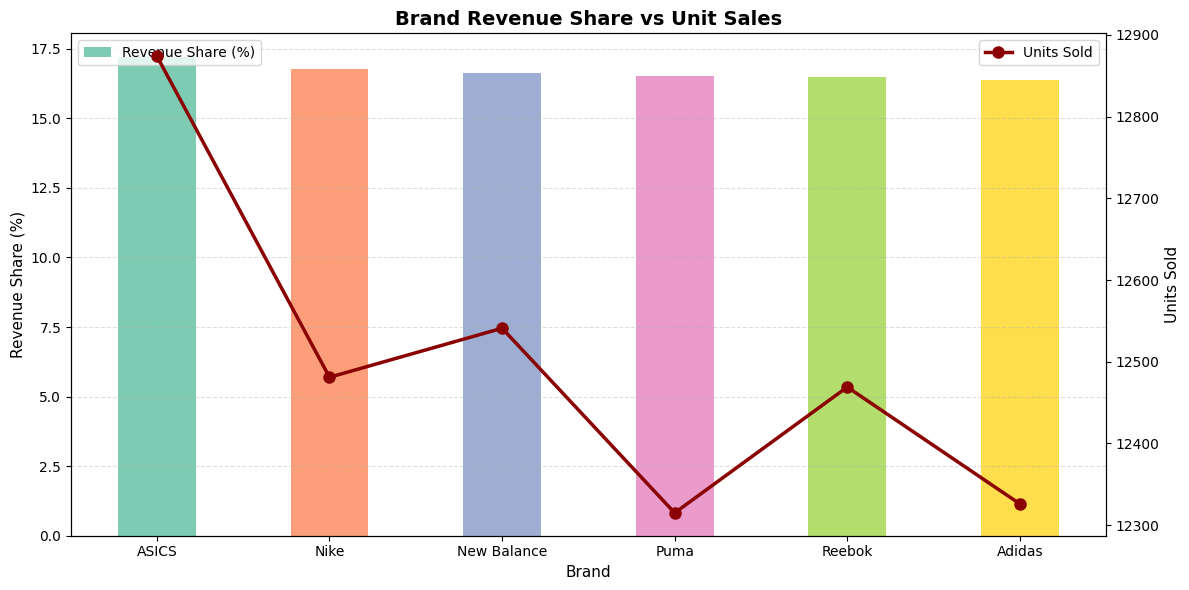

In [ ]:
# Sort by revenue share
plot_df = brand_summary.sort_values(
    "Revenue_Share_%",
    ascending=False
)

fig, ax1 = plt.subplots(figsize=(12,6))

# Color palette
colors = sns.color_palette("Set2", len(plot_df))

# Revenue Share Bars
bars = ax1.bar(
    plot_df["brand"],
    plot_df["Revenue_Share_%"],
    width=0.45,          # thinner bars
    color=colors,
    alpha=0.85,
    label="Revenue Share (%)"
)

ax1.set_ylabel("Revenue Share (%)", fontsize=11)
ax1.set_xlabel("Brand", fontsize=11)

# Second Axis
ax2 = ax1.twinx()

line = ax2.plot(
    plot_df["brand"],
    plot_df["Total_Units"],
    color="darkred",
    marker="o",
    linewidth=2.5,
    markersize=8,
    label="Units Sold"
)

ax2.set_ylabel("Units Sold", fontsize=11)

# Title
plt.title(
    "Brand Revenue Share vs Unit Sales",
    fontsize=14,
    fontweight="bold"
)

# Legends
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

# Grid
ax1.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

Detecting Pricing power by comparing Average asp and average discount

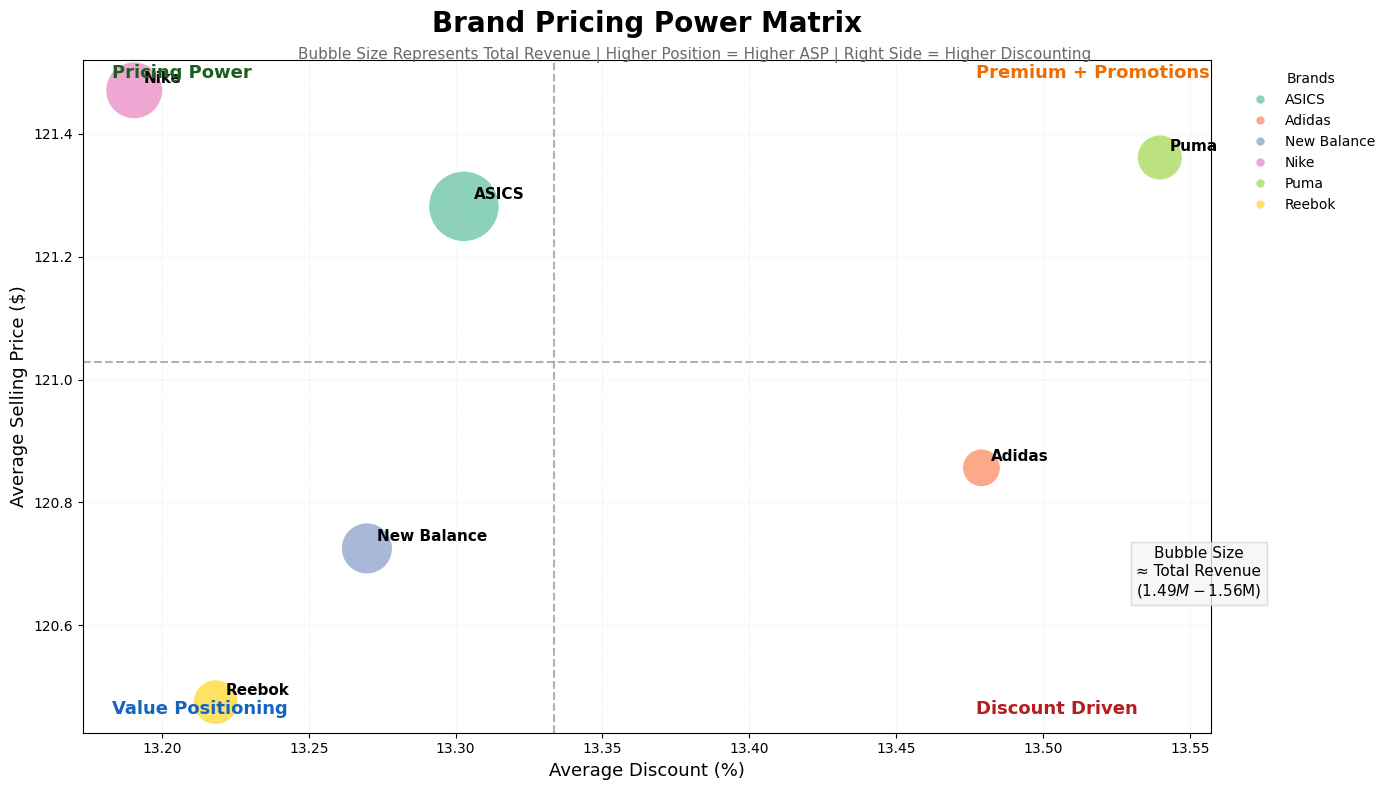

In [ ]:
# Mean values
mean_discount = brand_summary['Avg_Discount'].mean()
mean_price = brand_summary['Avg_Selling_Price'].mean()

# Modern palette
colors = sns.color_palette("pastel", len(brand_summary))

plt.figure(figsize=(14,8))

scatter = sns.scatterplot(
    data=brand_summary,
    x='Avg_Discount',
    y='Avg_Selling_Price',
    size='Total_Revenue',
    hue='brand',
    sizes=(700, 2500),
    palette='Set2',
    alpha=0.75,
    linewidth=0,       
    legend='full'
)

# Brand Labels
for _, row in brand_summary.iterrows():
    plt.annotate(
        row['brand'],
        (row['Avg_Discount'], row['Avg_Selling_Price']),
        xytext=(7,5),
        textcoords='offset points',
        fontsize=11,
        fontweight='bold'
    )

# Mean Lines
plt.axvline(
    mean_discount,
    linestyle='--',
    color='gray',
    alpha=0.6
)

plt.axhline(
    mean_price,
    linestyle='--',
    color='gray',
    alpha=0.6
)

# Subtle Quadrant Labels
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()

plt.text(
    xmin + 0.01,
    ymax - 0.03,
    "Pricing Power",
    fontsize=13,
    color='#1B5E20',
    fontweight='bold'
)

plt.text(
    xmax - 0.08,
    ymax - 0.03,
    "Premium + Promotions",
    fontsize=13,
    color='#EF6C00',
    fontweight='bold'
)

plt.text(
    xmin + 0.01,
    ymin + 0.03,
    "Value Positioning",
    fontsize=13,
    color='#1565C0',
    fontweight='bold'
)

plt.text(
    xmax - 0.08,
    ymin + 0.03,
    "Discount Driven",
    fontsize=13,
    color='#B71C1C',
    fontweight='bold'
)

# Title
plt.title(
    "Brand Pricing Power Matrix",
    fontsize=20,
    fontweight='bold',
    pad=20
)

# Subtitle
plt.figtext(
    0.5,
    0.92,
    "Bubble Size Represents Total Revenue | Higher Position = Higher ASP | Right Side = Higher Discounting",
    ha='center',
    fontsize=11,
    color='dimgray'
)

plt.xlabel("Average Discount (%)", fontsize=13)
plt.ylabel("Average Selling Price ($)", fontsize=13)

# Soft Grid
plt.grid(
    linestyle=':',
    alpha=0.25
)


handles, labels = scatter.get_legend_handles_labels()

# Keep only brand legend
brand_handles = handles[1:7]
brand_labels = labels[1:7]

plt.legend(
    brand_handles,
    brand_labels,
    title="Brands",
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False
)

# Revenue explanation
plt.figtext(
    0.86,
    0.25,
    "Bubble Size\n≈ Total Revenue\n($1.49M - $1.56M)",
    fontsize=11,
    ha='center',
    bbox=dict(
        facecolor='whitesmoke',
        alpha=0.8,
        edgecolor='lightgray'
    )
)

plt.tight_layout()
plt.show()

Key Insights:
1.The sports footwear market exhibits high competitive parity, with all brands operating within a narrow range of average selling prices and discount levels, indicating similar pricing strategies across the industry.                                   

2.ASICS emerges as the strongest overall performer, generating the highest revenue while maintaining above-average selling prices and below-average discount intensity. This suggests a balanced combination of scale, pricing discipline, and customer demand.

3.Nike demonstrates the strongest pricing power, achieving the highest average selling price while offering the lowest average discount. This indicates strong brand equity and reduced dependence on promotional activities to drive sales.

4.Puma occupies a premium but promotion-dependent position, maintaining high selling prices but also offering the highest discounts among all brands. This suggests that its premium positioning may be partially supported by promotional incentives.

5.Adidas shows signs of pricing inefficiency, as it provides above-average discounts while still achieving below-average realized selling prices. This indicates potential margin pressure and highlights the need to reassess its promotional strategy.

6.New Balance follows an efficient value-oriented strategy, competing through relatively lower prices while avoiding excessive discounting. The brand appears to focus on volume generation rather than premium pricing.

7.Reebok is positioned as the clearest value brand, offering the lowest average selling price with relatively low discount intensity. Its strategy appears to emphasize affordability rather than premium positioning.

8.Revenue differences across brands are relatively small, suggesting that no single brand dominates the market. Future growth opportunities are therefore likely to depend more on channel optimization, customer experience, geographic expansion, and product portfolio decisions rather than pricing alone.

9.The portfolio naturally segments into three strategic groups:

Premium Leaders: Nike and ASICS

Premium but Promotion-Supported: Puma

Value-Oriented Brands: New Balance and Reebok

Strategic Outlier Requiring Attention: Adidas


Strategic Recommendations

1.Preserve the pricing discipline of Nike and ASICS while leveraging their strong brand positioning to drive profitable growth.

2.Evaluate whether Puma's discount levels are generating sufficient incremental revenue to justify potential margin erosion.

3.Reassess Adidas' promotional strategy, as higher discounts are not translating into stronger price realization or premium positioning.

4.Continue strengthening the value propositions of New Balance and Reebok, which appear to compete effectively through affordability rather than heavy discounting.

5.Since pricing differences are minimal across brands, future competitive advantage should focus on channel effectiveness, customer satisfaction, product innovation, and geographic market expansion rather than further discount-based competition.

Analyzing Discount vs Satisfaction

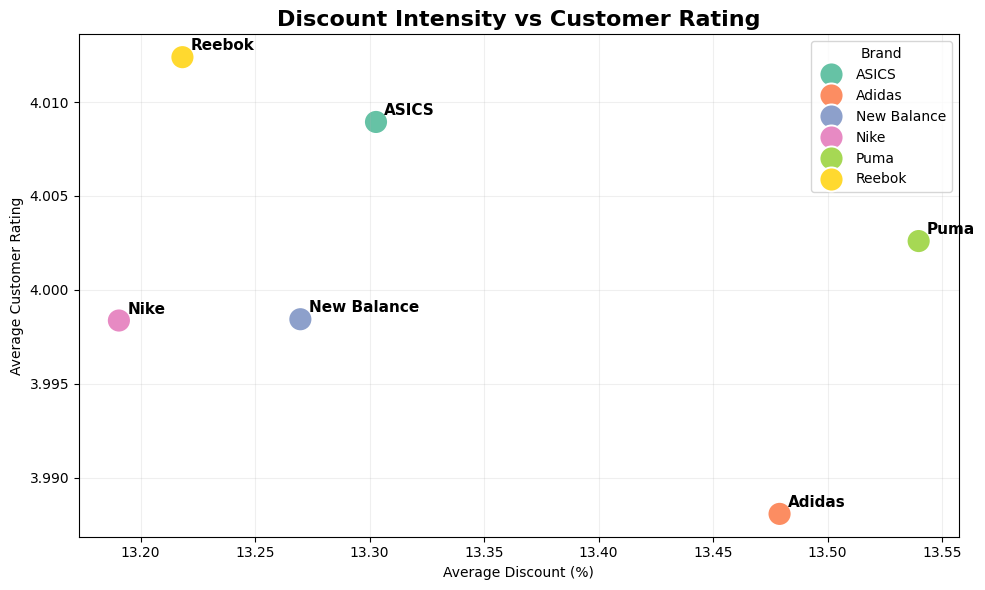

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=brand_summary,
    x='Avg_Discount',
    y='Avg_Rating',
    hue='brand',
    s=300,
    palette='Set2'
)

for _, row in brand_summary.iterrows():
    plt.annotate(
        row['brand'],
        (row['Avg_Discount'], row['Avg_Rating']),
        xytext=(6,5),
        textcoords='offset points',
        fontsize=11,
        fontweight='bold'
    )

plt.title(
    "Discount Intensity vs Customer Rating",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Average Discount (%)")
plt.ylabel("Average Customer Rating")

plt.grid(alpha=0.2)

plt.legend(title="Brand")

plt.tight_layout()
plt.show()

In [32]:
corr = brand_summary['Avg_Discount'].corr(
    brand_summary['Avg_Rating']
)

print(f"Correlation: {corr:.3f}")

Correlation: -0.414


Insights:

1.A moderate negative correlation (r = -0.414) exists between average discount levels and customer ratings, indicating that higher discounting is associated with slightly lower customer satisfaction.

2.Brands with lower promotional intensity, such as Reebok and ASICS, achieve the highest customer ratings, suggesting that strong product value and customer experience can outweigh price incentives.

3.Puma offers the highest average discounts but does not achieve proportionately higher ratings, indicating diminishing returns from discount-driven customer acquisition strategies.

4.Adidas presents the weakest performance, combining above-average discount intensity with the lowest customer rating, suggesting that discounts alone are insufficient to improve customer perception.

5.The findings indicate that customer satisfaction is influenced more by brand experience and product quality than by promotional activity.

6.Increasing discounts may support short-term sales objectives, but the analysis suggests that it is unlikely to generate sustainable improvements in customer satisfaction.

In short,
1.Nike → Strongest pricing power.

2.ASICS → Strongest overall performer (revenue + pricing + satisfaction).

3.Puma → Premium brand with growing promotion dependency.

4.Adidas → Strategic concern due to weak price realization and lowest customer satisfaction.

5.New Balance & Reebok → Successful value-oriented brands.

6.Discounting does not improve customer satisfaction

Discount Strategy Effectiveness

In [33]:
df['Discount_Band'].value_counts()

Discount_Band
0-10%     15034
11-20%     9963
21-30%     5003
Name: count, dtype: int64

In [13]:
discount_analysis = (
    df.groupby(['brand','Discount_Band'])
      .agg(
          Total_Revenue=('revenue_usd','sum'),
          Total_Units=('units_sold','sum'),
      )
      .reset_index()
)

C:\Users\HP\AppData\Local\Temp\ipykernel_8184\3734398093.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['brand','Discount_Band'])


In [14]:
discount_analysis

,brand,Discount_Band,Total_Revenue,Total_Units
0,ASICS,0-10%,858858.50,6464
1,ASICS,11-20%,489782.30,4230
2,ASICS,21-30%,212821.70,2180
3,Adidas,0-10%,795978.50,6047
4,Adidas,11-20%,488037.75,4230
5,Adidas,21-30%,202250.30,2049
6,New Balance,0-10%,821933.45,6234
7,New Balance,11-20%,483362.15,4212
8,New Balance,21-30%,206105.90,2095
9,Nike,0-10%,858401.00,6399


In [51]:
discount_analysis_v2 = (
    df.groupby('Discount_Band')
      .agg(
          Orders=('order_id','count'),
          Avg_Revenue_Per_Order=('revenue_usd','mean'),
          Avg_Units_Per_Order=('units_sold','mean'),
          Avg_Rating=('customer_rating','mean'),
          Avg_Final_Price=('final_price_usd','mean')
      )
      .reset_index()
)

discount_analysis_v2

C:\Users\HP\AppData\Local\Temp\ipykernel_21500\1207024085.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Discount_Band')


,Discount_Band,Orders,Avg_Revenue_Per_Order,Avg_Units_Per_Order,Avg_Rating,Avg_Final_Price
0,0-10%,15034,331.522459,2.497073,4.000512,132.777355
1,11-20%,9963,288.187293,2.498645,4.004376,115.169316
2,21-30%,5003,245.078913,2.512692,3.999001,97.394443


C:\Users\HP\AppData\Local\Temp\ipykernel_21500\207234165.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


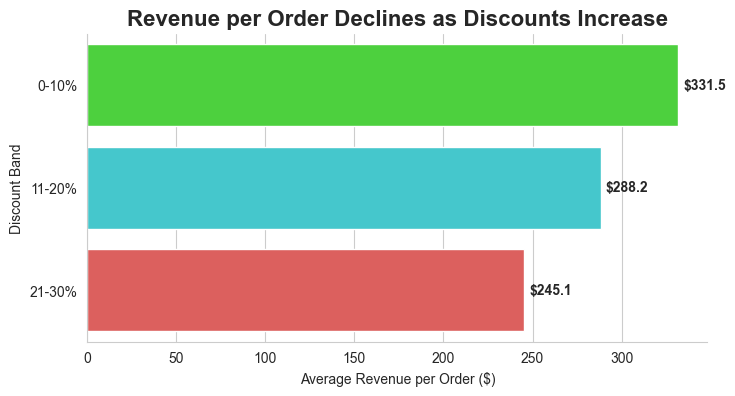

In [54]:
plt.figure(figsize=(8,4))

bars = sns.barplot(
    data=discount_analysis_v2,
    y='Discount_Band',
    x='Avg_Revenue_Per_Order',
    palette=["#39E826","#2FDCE2","#F14C49"]
)

for i, value in enumerate(discount_analysis_v2['Avg_Revenue_Per_Order']):
    plt.text(
        value + 3,
        i,
        f'${value:.1f}',
        va='center',
        fontweight='bold'
    )

plt.title(
    'Revenue per Order Declines as Discounts Increase',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Average Revenue per Order ($)')
plt.ylabel('Discount Band')

sns.despine()
plt.show()

Channel Strategy: Online vs Retail

In [69]:
channel_summary = (
    df.groupby('sales_channel')
      .agg(
          Orders=('order_id','count'),
          Total_Revenue=('revenue_usd','sum'),
          Total_Units=('units_sold','sum'),
          Avg_Discount=('discount_percent','mean'),
          Avg_Rating=('customer_rating','mean')
      )
      .reset_index()
)

channel_summary['AOV'] = (
    channel_summary['Total_Revenue']
    /
    channel_summary['Orders']
)

channel_summary.round(2)

,sales_channel,Orders,Total_Revenue,Total_Units,Avg_Discount,Avg_Rating,AOV
0,Online,14991,4540629.20,37527,13.42,4.0,302.89
1,Retail Store,15009,4540819.25,37479,13.25,4.0,302.54


In [71]:
brand_channel = (
    df.groupby(['brand','sales_channel'])
      ['revenue_usd']
      .sum()
      .unstack()
)

brand_channel

sales_channel,Online,Retail Store
brand,,
ASICS,773546.40,787916.10
Adidas,749047.15,737219.40
New Balance,747022.40,764379.10
Nike,782138.25,742443.85
Puma,735290.00,763804.90
Reebok,753585.00,745055.90


In [72]:
brand_channel_pct = (
    brand_channel['Online']
    /
    (
        brand_channel['Online']
        +
        brand_channel['Retail Store']
    )
    * 100
).reset_index()

brand_channel_pct.columns = [
    'brand',
    'Online_Revenue_Share'
]

C:\Users\HP\AppData\Local\Temp\ipykernel_21500\3928573457.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


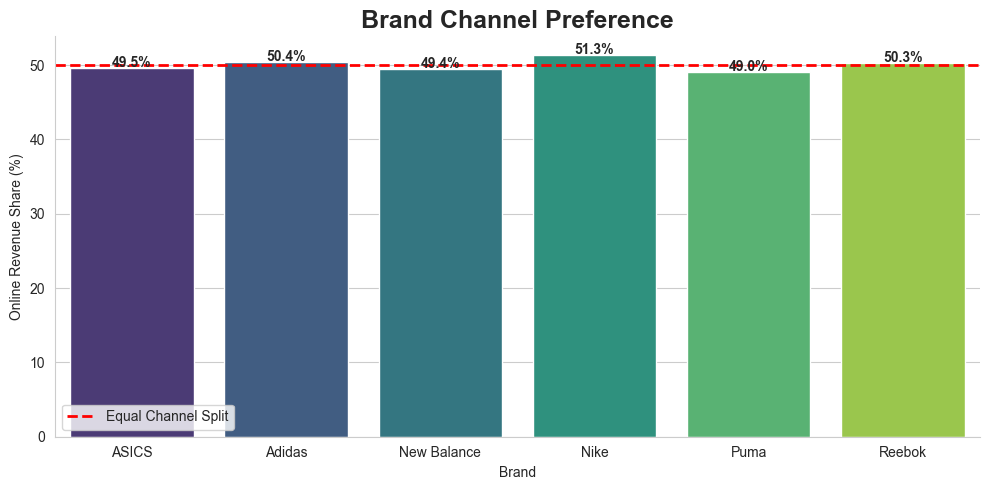

In [73]:
sns.set_style("whitegrid")

plt.figure(figsize=(10,5))

bars = sns.barplot(
    data=brand_channel_pct,
    x='brand',
    y='Online_Revenue_Share',
    palette='viridis'
)

# 50% reference line
plt.axhline(
    50,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Equal Channel Split'
)

# labels
for bar in bars.patches:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.15,
        f'{bar.get_height():.1f}%',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    'Brand Channel Preference',
    fontsize=18,
    fontweight='bold'
)

plt.ylabel('Online Revenue Share (%)')
plt.xlabel('Brand')

plt.legend()

sns.despine()

plt.tight_layout()

plt.show()

In [74]:
category_channel = (
    df.groupby(['category','sales_channel'])
      ['revenue_usd']
      .sum()
      .unstack()
)

category_channel

sales_channel,Online,Retail Store
category,,
Basketball,895397.35,926972.30
Gym,907955.05,864705.65
Lifestyle,915496.95,929131.80
Running,903942.05,901508.65
Training,917837.80,918500.85


In [75]:
category_channel_pct = (
    category_channel['Online']
    /
    (
        category_channel['Online']
        +
        category_channel['Retail Store']
    )
    * 100
).reset_index()

category_channel_pct.columns = [
    'category',
    'Online_Revenue_Share'
]

C:\Users\HP\AppData\Local\Temp\ipykernel_21500\120894564.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


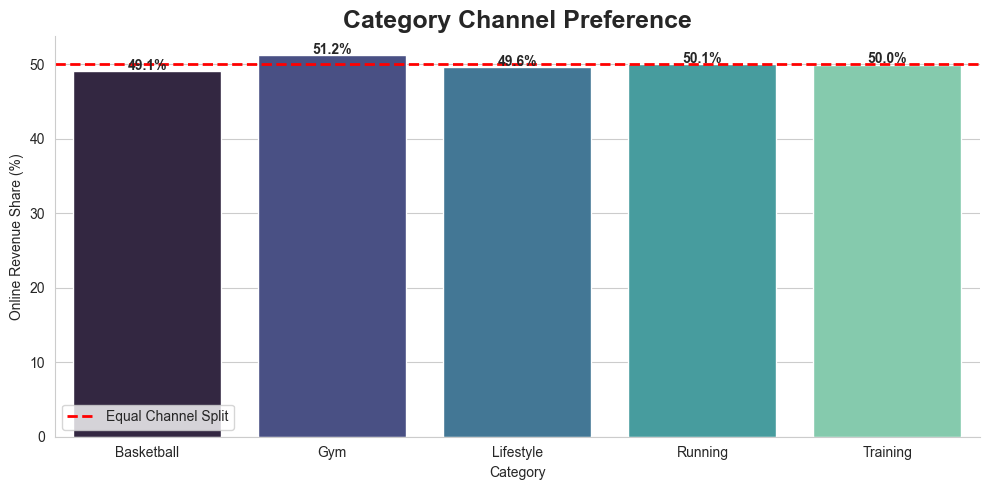

In [76]:
plt.figure(figsize=(10,5))

bars = sns.barplot(
    data=category_channel_pct,
    x='category',
    y='Online_Revenue_Share',
    palette='mako'
)

plt.axhline(
    50,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Equal Channel Split'
)

for bar in bars.patches:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.15,
        f'{bar.get_height():.1f}%',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    'Category Channel Preference',
    fontsize=18,
    fontweight='bold'
)

plt.ylabel('Online Revenue Share (%)')
plt.xlabel('Category')

plt.legend()

sns.despine()

plt.tight_layout()

plt.show()

1.Overall channel performance is highly balanced, with Online and Retail Store channels generating nearly identical revenue, order volume, customer satisfaction, and average order value.

2.Nike,Reebok and Adidas exhibit a stronger online presence, while ASICS and Puma generate relatively more revenue through retail stores.

3.Gym footwear shows stronger online performance, whereas Basketball and Lifestyle categories are more retail-oriented.

4.Discount dependency is nearly identical across channels, but little higher for online channel.

5.The company demonstrates a strong omnichannel model with no significant reliance on a single sales channel.

 Geographic Market Prioritization

In [110]:
country_metrics = (
    df.groupby('country')
      .agg(
          Total_Revenue=('revenue_usd', 'sum'),
          Units_Sold=('units_sold', 'sum'),
          Orders=('order_id', 'count'),
          Avg_Rating=('customer_rating', 'mean')
      )
)

# Average Order Value
country_metrics['AOV'] = (
    country_metrics['Total_Revenue']
    / country_metrics['Orders']
)

# Channel Mix (%)
channel_mix = (
    pd.crosstab(
        df['country'],
        df['sales_channel'],
        normalize='index'
    ) * 100
)

channel_mix.columns = [
    f'{col}_%' for col in channel_mix.columns
]

# Income Composition (%)
income_mix = (
    pd.crosstab(
        df['country'],
        df['customer_income_level'],
        normalize='index'
    ) * 100
)

income_mix.columns = [
    f'{col}_Income_%'
    for col in income_mix.columns
]

# Final Country Profile Table
country_profile = pd.concat(
    [country_metrics, channel_mix, income_mix],
    axis=1
)

country_profile = country_profile.reset_index()

country_profile = country_profile.round({
    'Total_Revenue': 0,
    'Units_Sold': 0,
    'AOV': 2,
    'Avg_Rating': 2
})

country_profile

,country,Total_Revenue,Units_Sold,Orders,Avg_Rating,AOV,Online_%,Retail Store_%,High_Income_%,Low_Income_%,Medium_Income_%
0,Germany,1503895.0,12452,4965,4.00,302.90,50.412890,49.587110,33.353474,33.736153,32.910373
1,India,1520899.0,12539,4991,4.00,304.73,49.769585,50.230415,34.041274,33.961130,31.997596
2,Pakistan,1466165.0,12063,4841,4.01,302.86,49.307994,50.692006,34.352407,32.555257,33.092336
3,UAE,1546443.0,12818,5118,4.01,302.16,50.058617,49.941383,32.981633,31.906995,35.111372
4,UK,1532300.0,12662,5058,4.00,302.95,50.158165,49.841835,32.957691,34.124160,32.918149
5,USA,1511747.0,12472,5027,3.99,300.73,50.089517,49.910483,33.538890,32.603939,33.857171


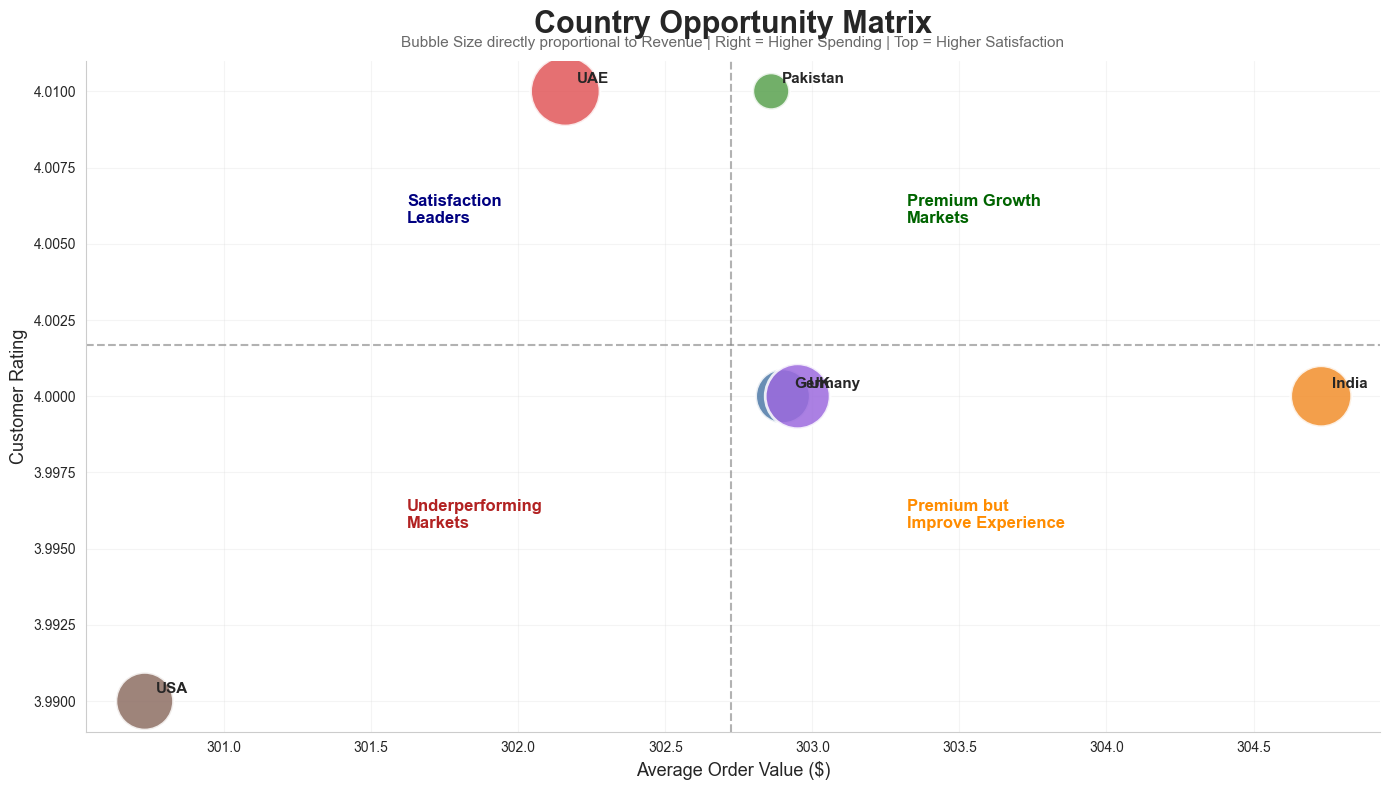

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,8))

palette = {
    'Germany':'#4E79A7',
    'India':'#F28E2B',
    'Pakistan':'#59A14F',
    'UAE':'#E15759',
    'UK':'#9C6ADE',
    'USA':'#8D6E63'
}

# Bubble Chart
sns.scatterplot(
    data=country_profile,
    x='AOV',
    y='Avg_Rating',
    size='Total_Revenue',
    hue='country',
    palette=palette,
    sizes=(700,2500),
    alpha=0.85,
    edgecolor='white',
    linewidth=2,
    legend=False
)

# Labels
for _, row in country_profile.iterrows():
    plt.annotate(
        row['country'],
        (row['AOV'], row['Avg_Rating']),
        xytext=(8,6),
        textcoords='offset points',
        fontsize=11,
        fontweight='bold'
    )

# Reference Lines
avg_aov = country_profile['AOV'].mean()
avg_rating = country_profile['Avg_Rating'].mean()

plt.axvline(
    avg_aov,
    linestyle='--',
    color='gray',
    alpha=0.6
)

plt.axhline(
    avg_rating,
    linestyle='--',
    color='gray',
    alpha=0.6
)

# Quadrant Labels
plt.text(
    avg_aov+0.6,
    avg_rating+0.004,
    'Premium Growth\nMarkets',
    fontsize=12,
    fontweight='bold',
    color='darkgreen'
)

plt.text(
    avg_aov-1.1,
    avg_rating+0.004,
    'Satisfaction\nLeaders',
    fontsize=12,
    fontweight='bold',
    color='navy'
)

plt.text(
    avg_aov+0.6,
    avg_rating-0.006,
    'Premium but\nImprove Experience',
    fontsize=12,
    fontweight='bold',
    color='darkorange'
)

plt.text(
    avg_aov-1.1,
    avg_rating-0.006,
    'Underperforming\nMarkets',
    fontsize=12,
    fontweight='bold',
    color='firebrick'
)

# Titles
plt.title(
    'Country Opportunity Matrix',
    fontsize=22,
    fontweight='bold',
    pad=20
)

plt.text(
    0.5,
    1.02,
    'Bubble Size directly proportional to Revenue | Right = Higher Spending | Top = Higher Satisfaction',
    transform=plt.gca().transAxes,
    ha='center',
    fontsize=11,
    color='dimgray'
)

plt.xlabel(
    'Average Order Value ($)',
    fontsize=13
)

plt.ylabel(
    'Customer Rating',
    fontsize=13
)

# Clean Styling
sns.despine()
plt.grid(alpha=0.2)

plt.tight_layout()

plt.show()

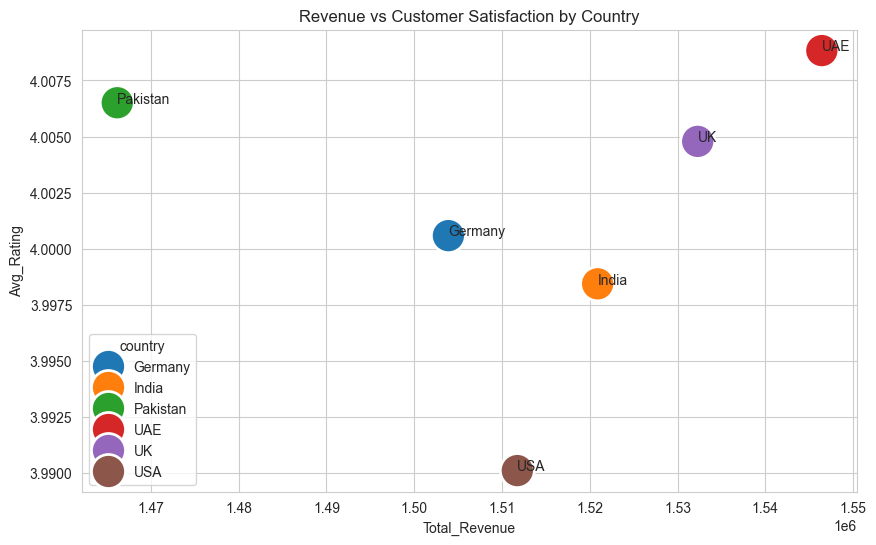

In [107]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=country_summary,
    x='Total_Revenue',
    y='Avg_Rating',
    s=600,
    hue='country'
)

for _, row in country_summary.iterrows():
    plt.annotate(
        row['country'],
        (row['Total_Revenue'], row['Avg_Rating'])
    )

plt.title('Revenue vs Customer Satisfaction by Country')
plt.show()

1.UAE is the strongest overall market, generating the highest revenue while maintaining the highest customer satisfaction and medium income people buys more than other segments.

2.India demonstrates the highest spending power (AOV), indicating stronger premium purchasing behavior, although customer satisfaction remains average.

3.Pakistan has the highest concentration of high-income customers and one of the highest satisfaction scores, yet generates the lowest revenue, suggesting significant growth potential through increased market penetration.

4.The UK achieves strong revenue performance despite having the largest share of low-income customers, highlighting broad market reach across income segments.

5.Channel preferences are remarkably consistent across countries, with Online and Retail channels contributing almost equally to sales, indicating a globally balanced omnichannel strategy.

6.USA records both the lowest customer satisfaction and lowest average order value, making it the primary market for customer experience and value enhancement initiatives

1.Markets with Strongest Premium Demand:

India – Highest average order value, indicating the strongest willingness to spend.

UK – Strong combination of spending power and revenue scale.

Germany – Stable premium purchasing behavior.

2.Markets Recommended for Incremental Growth Investments:

UAE – Highest revenue, highest unit sales, and highest customer satisfaction.

India – Strongest premium demand and significant monetization potential.

UK – Balanced performance and scalable premium market.

3.Markets Requiring Strategic Attention:

USA: Improve customer experience and value perception.

Pakistan: High satisfaction but limited market scale; focus on expansion and customer acquisition.

Consumer Segmentation by Income Level

In [33]:
income_summary = (
    df.groupby('customer_income_level')
      .agg(
          Orders=('order_id','count'),
          Total_Revenue=('revenue_usd','sum'),
          Units_Sold=('units_sold','sum'),
          Avg_Order_Value=('revenue_usd','mean'),
          Avg_Final_Price=('final_price_usd','mean'),
          Avg_Discount=('discount_percent','mean'),
          Avg_Rating=('customer_rating','mean')
      )
      .reset_index()
      .sort_values(by='Total_Revenue',ascending=False)
)

income_summary

,customer_income_level,Orders,Total_Revenue,Units_Sold,Avg_Order_Value,Avg_Final_Price,Avg_Discount,Avg_Rating
1,Low,9944,3040581.20,24966,305.770434,121.855727,13.245676,4.000553
0,High,10059,3037804.30,25196,301.998638,120.553554,13.351228,3.997137
2,Medium,9997,3003062.95,24844,300.396414,120.685156,13.399020,4.006962


1.No of units sold were greater for high income but that segment generated lesser revenue than low income segment.This is also evident from average order value.

2.Medium income segment prefers more discount compartively to other segments.

3.Although high income people buy more stuff but have lower avg_order_value so the revenue as compared to low income level segment

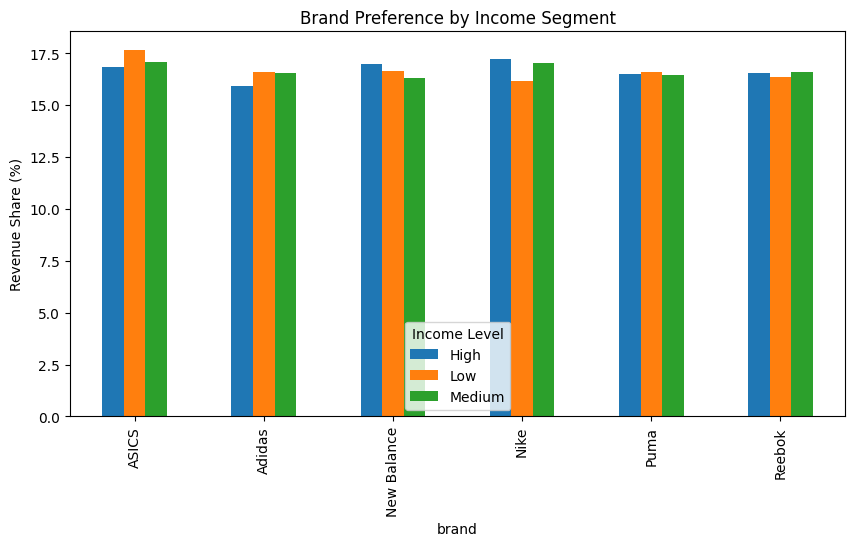

In [17]:
brand_pref = pd.pivot_table(
    df,
    values='revenue_usd',
    index='customer_income_level',
    columns='brand',
    aggfunc='sum'
)

brand_share = (
    brand_pref.div(brand_pref.sum(axis=1), axis=0)
    * 100
)

brand_share.T.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Brand Preference by Income Segment')
plt.ylabel('Revenue Share (%)')
plt.legend(title='Income Level')
plt.show()

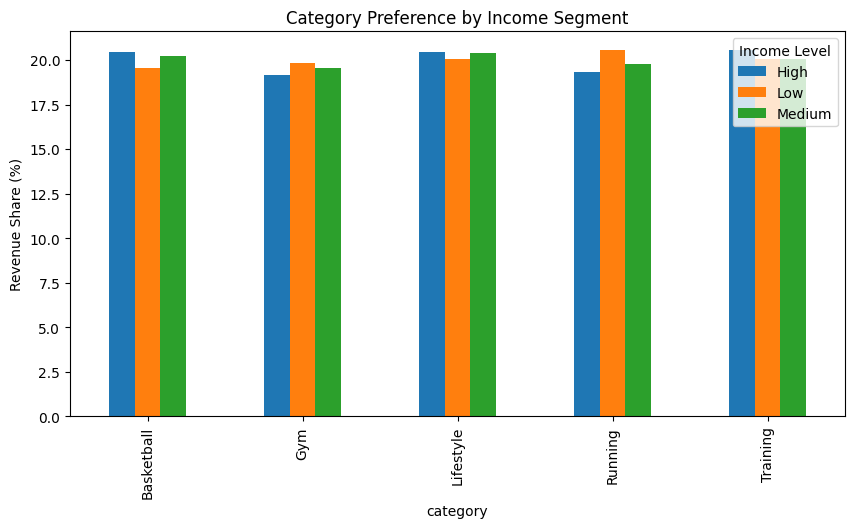

In [ ]:
category_pref = pd.pivot_table(
    df,
    values='revenue_usd',
    index='customer_income_level',
    columns='category',
    aggfunc='sum'
)

category_share = (
    category_pref.div(category_pref.sum(axis=1), axis=0)
    * 100
)

category_share.T.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Category Preference by Income Segment')
plt.ylabel('Revenue Share (%)')
plt.legend(title='Income Level',loc='lower left')
plt.show()

In [34]:
price_analysis = pd.pivot_table(
    df,
    values='final_price_usd',
    index='Discount_Band',
    columns='customer_income_level',
    aggfunc='mean'
)

print(price_analysis.round(2))

customer_income_level    High     Low  Medium
Discount_Band                                
0-10%                  132.32  133.82  132.19
11-20%                 115.10  114.72  115.70
21-30%                  96.38   99.16   96.75


C:\Users\HP\AppData\Local\Temp\ipykernel_25488\2767854764.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  price_analysis = pd.pivot_table(


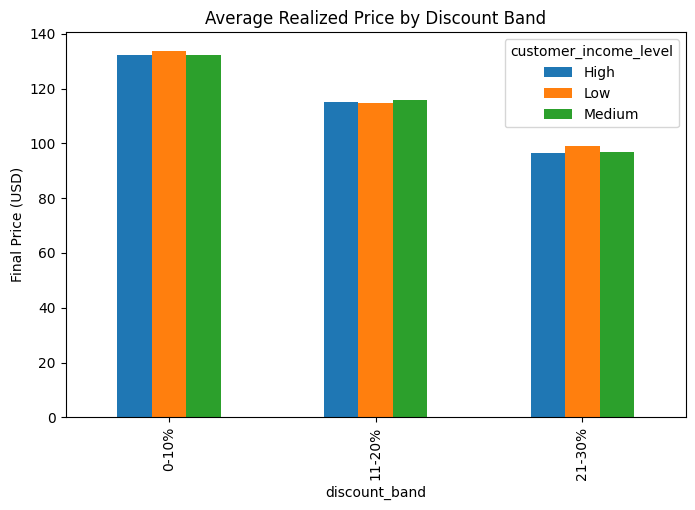

In [21]:
price_analysis.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Average Realized Price by Discount Band')
plt.ylabel('Final Price (USD)')
plt.show()

Lesser Discount is preferred

In [22]:
top_brands = (
    df.groupby(['customer_income_level','brand'])['revenue_usd']
      .sum()
      .reset_index()
      .sort_values(
          ['customer_income_level','revenue_usd'],
          ascending=[True,False]
      )
)

print(top_brands.groupby('customer_income_level').head(3))

   customer_income_level        brand  revenue_usd
3                   High         Nike    522474.80
2                   High  New Balance    515424.00
0                   High        ASICS    511998.05
6                    Low        ASICS    537040.85
8                    Low  New Balance    506052.95
7                    Low       Adidas    505211.45
12                Medium        ASICS    512423.60
15                Medium         Nike    510960.85
17                Medium       Reebok    498310.85


1.ASICS is a mass premium brand.Mostly bought by low and medium level income segment.

2.Nike is a premium brand mostly worn by high and middle class people.

In [23]:
top_categories = (
    df.groupby(['customer_income_level','category'])['revenue_usd']
      .sum()
      .reset_index()
      .sort_values(
          ['customer_income_level','revenue_usd'],
          ascending=[True,False]
      )
)

print(top_categories.groupby('customer_income_level').head(3))

   customer_income_level    category  revenue_usd
4                   High    Training    624941.05
2                   High   Lifestyle    621808.35
0                   High  Basketball    621643.20
8                    Low     Running    624397.85
7                    Low   Lifestyle    609605.80
9                    Low    Training    609546.20
12                Medium   Lifestyle    613214.60
10                Medium  Basketball    606581.55
14                Medium    Training    601851.40


Product Category Strategy


category level trend over time

In [39]:

category_trend = (
    df.groupby(['Year','category'])
      .agg(
          Revenue=('revenue_usd','sum'),
          Units=('units_sold','sum')
      )
      .reset_index()
)

category_trend.head()

,Year,category,Revenue,Units
0,2018,Basketball,205001.75,1704
1,2018,Gym,191728.90,1555
2,2018,Lifestyle,201744.70,1632
3,2018,Running,201359.35,1678
4,2018,Training,190545.50,1612


In [41]:
pivot_rev = category_trend.pivot(
    index='Year',
    columns='category',
    values='Revenue'
)

growth = (
    (pivot_rev.iloc[-1] / pivot_rev.iloc[0] - 1)
    * 100
).sort_values(ascending=False)

print(growth)

category
Training      16.264672
Lifestyle     -0.539295
Running       -3.086869
Gym           -3.399096
Basketball    -5.148371
dtype: float64


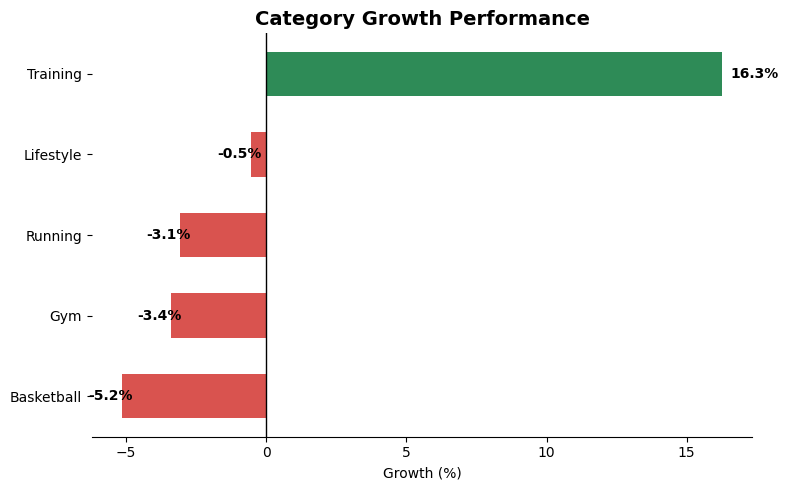

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

growth = {
    'Training': 16.26,
    'Lifestyle': -0.54,
    'Running': -3.09,
    'Gym': -3.40,
    'Basketball': -5.15
}

growth = pd.Series(growth).sort_values()

colors = ['#D9534F' if x < 0 else '#2E8B57'
          for x in growth.values]

plt.figure(figsize=(8,5))

bars = plt.barh(
    growth.index,
    growth.values,
    color=colors,
    height=0.55
)

plt.axvline(0, color='black', linewidth=1)

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.3 if width > 0 else width - 1.2,
        bar.get_y() + bar.get_height()/2,
        f'{width:.1f}%',
        va='center',
        fontweight='bold'
    )

plt.title(
    'Category Growth Performance',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Growth (%)')
plt.ylabel('')
sns.despine(left=True)
plt.tight_layout()
plt.show()

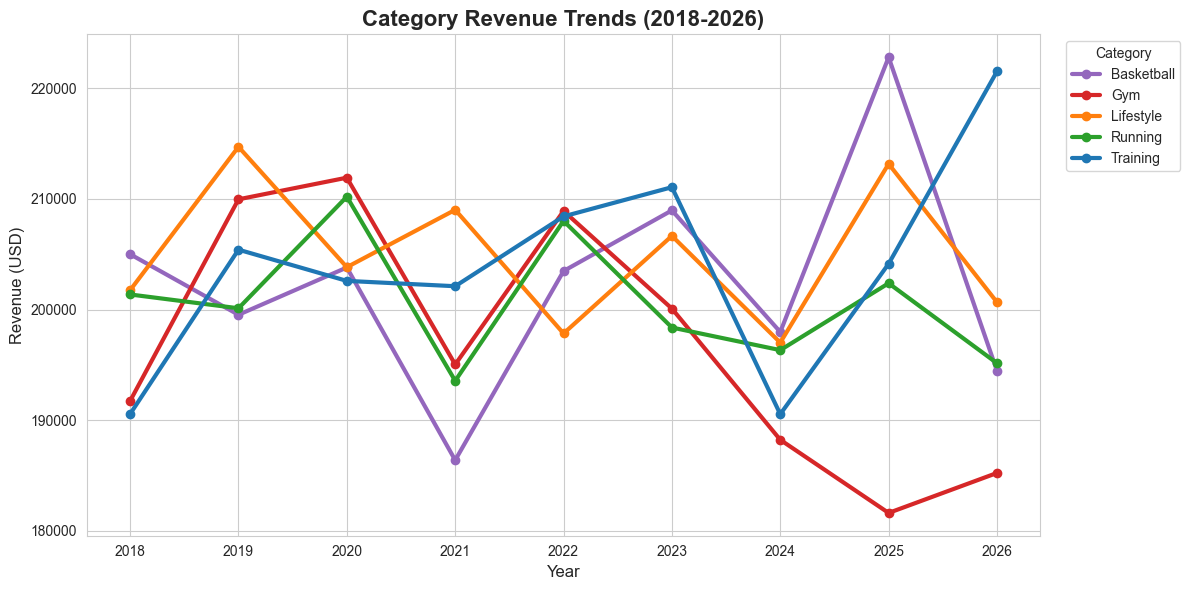

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract year
df['year'] = pd.to_datetime(df['order_date']).dt.year

# Revenue trend
category_trend = (
    df.groupby(['year', 'category'])['revenue_usd']
      .sum()
      .reset_index()
)

pivot_trend = category_trend.pivot(
    index='year',
    columns='category',
    values='revenue_usd'
)

# Plot
plt.figure(figsize=(12,6))

sns.set_style("whitegrid")

colors = {
    'Training':'#1f77b4',
    'Lifestyle':'#ff7f0e',
    'Running':'#2ca02c',
    'Gym':'#d62728',
    'Basketball':'#9467bd'
}

for col in pivot_trend.columns:
    plt.plot(
        pivot_trend.index,
        pivot_trend[col],
        marker='o',
        linewidth=3,
        label=col,
        color=colors.get(col)
    )

plt.title(
    "Category Revenue Trends (2018-2026)",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Revenue (USD)", fontsize=12)

plt.legend(
    title="Category",
    bbox_to_anchor=(1.02,1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

Pricing Differences Across Categories

In [42]:
pricing = (
    df.groupby('category')
      .agg(
          Avg_Base_Price=('base_price_usd','mean'),
          Avg_Final_Price=('final_price_usd','mean'),
          Avg_Discount=('discount_percent','mean'),
          Revenue=('revenue_usd','sum')
      )
      .round(2)
      .sort_values('Avg_Final_Price', ascending=False)
)

pricing

,Avg_Base_Price,Avg_Final_Price,Avg_Discount,Revenue
category,,,,
Lifestyle,140.60,121.92,13.29,1844628.75
Training,140.05,121.58,13.21,1836338.65
Gym,139.73,120.91,13.46,1772660.70
Running,139.52,120.80,13.45,1805450.70
Basketball,138.28,119.93,13.26,1822369.65


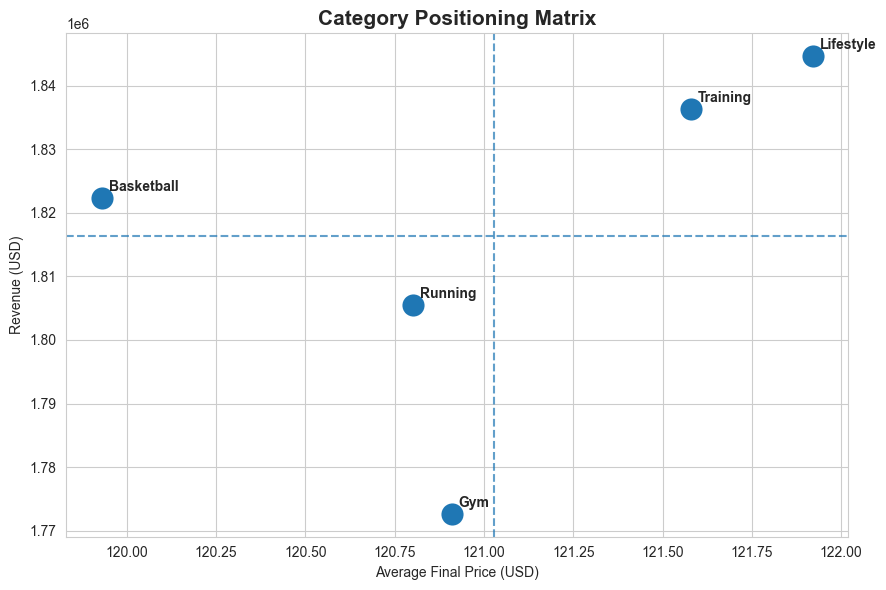

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9,6))

sns.scatterplot(
    data=pricing,
    x='Avg_Final_Price',
    y='Revenue',
    s=300
)

for category in pricing.index:
    plt.annotate(
        category,
        (
            pricing.loc[category, 'Avg_Final_Price'],
            pricing.loc[category, 'Revenue']
        ),
        xytext=(5,5),
        textcoords='offset points',
        fontsize=10,
        fontweight='bold'
    )

plt.axvline(
    pricing['Avg_Final_Price'].mean(),
    linestyle='--',
    alpha=0.7
)

plt.axhline(
    pricing['Revenue'].mean(),
    linestyle='--',
    alpha=0.7
)

plt.title(
    'Category Positioning Matrix',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Average Final Price (USD)')
plt.ylabel('Revenue (USD)')

plt.tight_layout()
plt.show()

Quadrants:

Top Right → High Revenue + High Price = Star Categories

Top Left → High Revenue + Low Price = Growth Drivers

Bottom Right → Low Revenue + High Price = Margin Stabilizers

Bottom Left → Low Revenue + Low Price = Underperformers

Gender Preferences

In [44]:
gender_pref = pd.pivot_table(
    df,
    values='revenue_usd',
    index='gender',
    columns='category',
    aggfunc='sum'
)

gender_share = (
    gender_pref.div(
        gender_pref.sum(axis=1),
        axis=0
    ) * 100
)

gender_share.round(2)

category,Basketball,Gym,Lifestyle,Running,Training
gender,,,,,
Men,19.87,19.28,20.26,19.90,20.68
Unisex,20.31,19.30,20.52,20.14,19.74
Women,20.03,19.97,20.16,19.61,20.24


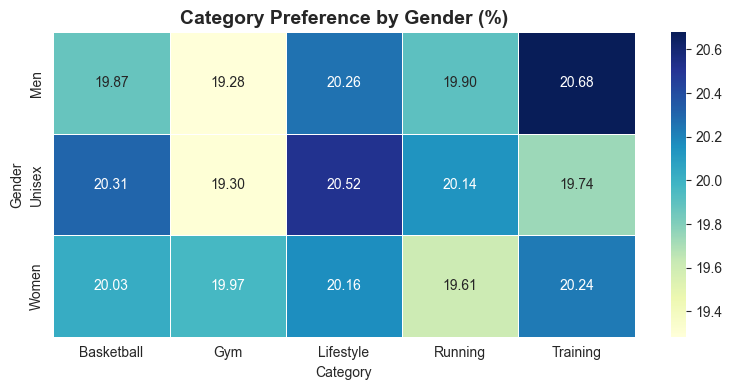

In [55]:
plt.figure(figsize=(8,4))

sns.heatmap(
    gender_share,      # your pivot table
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    linewidths=0.5
)

plt.title(
    'Category Preference by Gender (%)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Category')
plt.ylabel('Gender')

plt.tight_layout()
plt.show()

Cross-Country Performance Consistency

In [45]:
country_cat = pd.pivot_table(
    df,
    values='revenue_usd',
    index='country',
    columns='category',
    aggfunc='sum'
)

country_cat.head()

category,Basketball,Gym,Lifestyle,Running,Training
country,,,,,
Germany,289470.60,295995.25,309926.95,309489.30,299012.75
India,304716.45,292233.95,320533.25,298836.55,304578.75
Pakistan,294458.85,281024.45,299476.10,283644.20,307561.00
UAE,318204.70,300750.90,307348.15,312108.55,308030.25
UK,323219.00,305481.85,302688.35,298843.85,302067.00


In [56]:
country_category = (
    df.groupby(['country', 'category'])['revenue_usd']
      .sum()
      .reset_index()
)

top_category = (
    country_category
      .sort_values(
          ['country', 'revenue_usd'],
          ascending=[True, False]
      )
      .groupby('country')
      .first()
      .reset_index()
)

print(top_category)

    country    category  revenue_usd
0   Germany   Lifestyle    309926.95
1     India   Lifestyle    320533.25
2  Pakistan    Training    307561.00
3       UAE  Basketball    318204.70
4        UK  Basketball    323219.00
5       USA    Training    315088.90


In [61]:
top_cat = country_cat.idxmax(axis=1)
top_rev = country_cat.max(axis=1)

top_df = pd.DataFrame({
    'Country': top_cat.index,
    'Top_Category': top_cat.values,
    'Revenue': top_rev.values
})

In [63]:
top_df = top_df.sort_values(
    by='Revenue',
    ascending=False
)

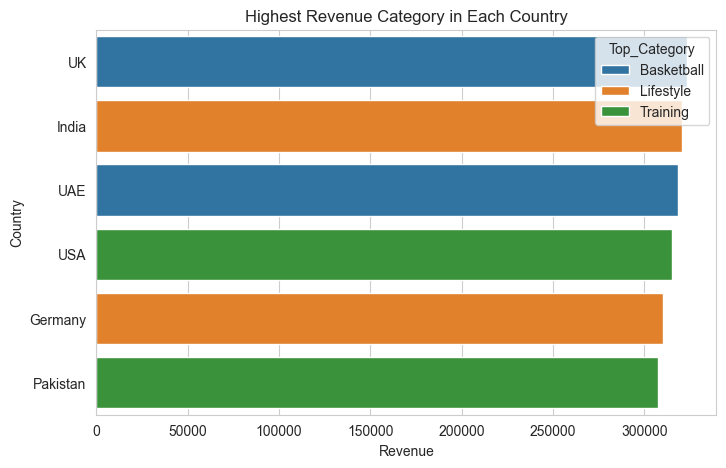

In [64]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=top_df,
    x='Revenue',
    y='Country',
    hue='Top_Category'
)

plt.title(
    'Highest Revenue Category in Each Country'
)

plt.show()

In [46]:
consistency = (
    df.groupby('category')
      .agg(
          Mean_Revenue=('revenue_usd','mean'),
          Std_Revenue=('revenue_usd','std')
      )
)

consistency['CV'] = (
    consistency['Std_Revenue'] /
    consistency['Mean_Revenue']
)

consistency.sort_values('CV')

,Mean_Revenue,Std_Revenue,CV
category,,,
Training,305.141019,177.468337,0.581594
Lifestyle,304.444422,179.861226,0.590785
Gym,302.192414,179.188635,0.592962
Running,301.763446,179.864095,0.596043
Basketball,300.027931,179.362635,0.597820


CV is coefficient of variance.It is equal to standard deviation / mean.

1.Training is the most geographically consistent category (lowest CV).

2.Basketball is the least consistent category (highest CV).

3.However, the spread between the highest and lowest CV is only ~0.016.

4.Therefore, category performance is remarkably stable across countries.

5.This suggests a globally balanced portfolio, with no category showing strong dependence on a specific market.

In [47]:
category_summary = (
    df.groupby('category')
      .agg(
          Revenue=('revenue_usd','sum'),
          Units=('units_sold','sum'),
          Avg_Final_Price=('final_price_usd','mean'),
          Avg_Discount=('discount_percent','mean'),
          Rating=('customer_rating','mean')
      )
)

category_summary['Revenue_per_Unit'] = (
    category_summary['Revenue'] /
    category_summary['Units']
)

category_summary.sort_values('Revenue', ascending=False)

,Revenue,Units,Avg_Final_Price,Avg_Discount,Rating,Revenue_per_Unit
category,,,,,,
Lifestyle,1844628.75,15129,121.923676,13.286021,3.992144,121.926681
Training,1836338.65,15142,121.575033,13.206215,3.999269,121.274511
Basketball,1822369.65,15160,119.928630,13.259796,3.997284,120.209080
Running,1805450.70,14928,120.804496,13.453117,4.014374,120.943911
Gym,1772660.70,14647,120.913254,13.460621,4.004910,121.025514


In [49]:
avg_units = category_summary['Units'].mean()
avg_rpu = category_summary['Revenue_per_Unit'].mean()

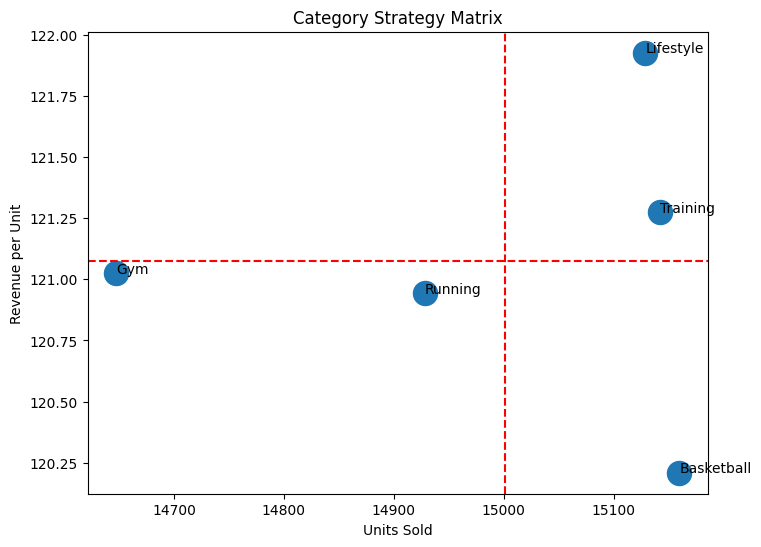

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    category_summary['Units'],
    category_summary['Revenue_per_Unit'],
    s=300
)

for cat in category_summary.index:
    plt.annotate(
        cat,
        (
            category_summary.loc[cat,'Units'],
            category_summary.loc[cat,'Revenue_per_Unit']
        )
    )

plt.axvline(avg_units, linestyle='--', color='red')
plt.axhline(avg_rpu, linestyle='--', color='red')

plt.xlabel('Units Sold')
plt.ylabel('Revenue per Unit')
plt.title('Category Strategy Matrix')

plt.show()

1.Lifestyle is the strongest category overall, combining the highest revenue per unit with high sales volume.

2.Training is another high-performing category, delivering both scale and pricing power.

3.Basketball drives volume but lacks pricing strength, making it a growth driver rather than a margin driver.

4.Running and Gym lag behind on both volume and pricing metrics, indicating opportunities for repositioning or portfolio optimization.